In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tcn import TCN
import os

In [2]:
overview_data = pd.read_excel("data\\0list.xlsx")

In [3]:
X = []
y = []

for idx, row in overview_data.iterrows():
    patient_num = row['Patient']
    disease_type = int(row['Score (type)'])

    healthy_file = pd.read_csv(f'data/Resultados/Elastome_{int(patient_num):04d}_Healthy_angle_1.csv')
    patho_file = pd.read_csv(f'data/Resultados/Elastome_{int(patient_num):04d}_Patho_angle_1.csv')

    X.append(healthy_file.values)
    y.append(6)
    X.append(patho_file.values)
    y.append(disease_type)

In [4]:
X = np.array(X)
y = np.array(y)

# Remap y to 0-based classes
unique_y = np.unique(y)
y_map = {val: i for i, val in enumerate(unique_y)}
y = np.array([y_map[val] for val in y])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_shape = X_train.shape
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
scaler.fit(X_train_reshaped)
X_train = scaler.transform(X_train_reshaped).reshape(X_train_shape)
X_val_reshaped = X_val.reshape(-1, X_val.shape[-1])
X_val = scaler.transform(X_val_reshaped).reshape(X_val.shape)

In [5]:
num_classes = len(np.unique(y))
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    TCN(nb_filters=32, kernel_size=3, dilations=[1,2,4,8], dropout_rate=0.2),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32)

d:\Anaconda\envs\epf\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.0625 - loss: nan - val_accuracy: 0.1250 - val_loss: nan
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.0625 - loss: nan - val_accuracy: 0.1250 - val_loss: nan
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.0625 - loss: nan - val_accuracy: 0.1250 - val_loss: nan
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.0625 - loss: nan - val_accuracy: 0.1250 - val_loss: nan
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.0625 - loss: nan - val_accuracy: 0.1250 - val_loss: nan
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.0625 - loss: nan - val_accuracy: 0.1250 - val_loss: nan
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.0625 - loss: nan - val_accuracy: 0.1250 - val_loss: nan
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.0625 - loss: nan - val_accuracy: 0.1250 - val_loss: nan
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345

Dropped 11 features with NaN values
Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1562 - loss: 3.7051 - val_accuracy: 0.3750 - val_loss: 2.0020
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.1562 - loss: 2.9569 - val_accuracy: 0.1250 - val_loss: 1.9587
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.1250 - loss: 3.0645 - val_accuracy: 0.1250 - val_loss: 1.9278
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.1875 - loss: 3.2519 - val_accuracy: 0.1250 - val_loss: 1.8897
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.0625 - loss: 2.7458 - val_accuracy: 0.1250 - val_loss: 1.8540
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.1562 - loss: 2.3440 - val_accuracy: 0.1250 - val_loss: 1.8269
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.1562 - loss: 2.2153 - val_accuracy: 0.3750 - val_loss: 1.8004
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.3125 - loss: 2.0571 -

d:\Anaconda\envs\epf\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\Anaconda\envs\epf\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\Anaconda\envs\epf\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\Anaconda\envs\epf\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\Anaconda\envs\epf\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\Anaconda\envs\epf\Lib\site-packages\sklearn\metric

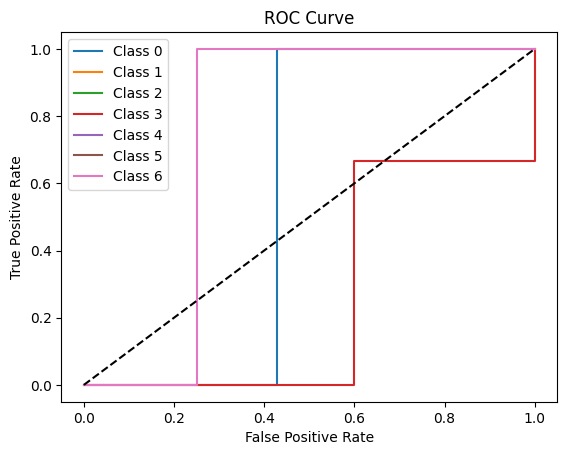

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tcn import TCN
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

overview_data = pd.read_excel("data\\0list.xlsx")

X = []
y = []

for idx, row in overview_data.iterrows():
    patient_num = row['Patient']
    disease_type = int(row['Score (type)'])

    healthy_file = pd.read_csv(f'data/Resultados/Elastome_{int(patient_num):04d}_Healthy_angle_1.csv')
    patho_file = pd.read_csv(f'data/Resultados/Elastome_{int(patient_num):04d}_Patho_angle_1.csv')

    X.append(healthy_file.values)
    y.append(6)
    X.append(patho_file.values)
    y.append(disease_type)

X = np.array(X)
y = np.array(y)

# Check for NaN and drop columns with NaN
if np.isnan(X).any():
    nan_mask = np.isnan(X).any(axis=(0,1))  # True for features with NaN in any sample/time
    X = X[:, :, ~nan_mask]
    print(f"Dropped {nan_mask.sum()} features with NaN values")

# Remap y to 0-based classes
unique_y = np.unique(y)
y_map = {val: i for i, val in enumerate(unique_y)}
y = np.array([y_map[val] for val in y])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_shape = X_train.shape
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
scaler.fit(X_train_reshaped)
X_train = scaler.transform(X_train_reshaped).reshape(X_train_shape)
X_val_reshaped = X_val.reshape(-1, X_val.shape[-1])
X_val = scaler.transform(X_val_reshaped).reshape(X_val.shape)

num_classes = len(np.unique(y))
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    TCN(nb_filters=32, kernel_size=3, dilations=[1,2,4,8], dropout_rate=0.2),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32)




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
AUC: nan


d:\Anaconda\envs\epf\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\Anaconda\envs\epf\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\Anaconda\envs\epf\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\Anaconda\envs\epf\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\Anaconda\envs\epf\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\Anaconda\envs\epf\Lib\site-packages\sklearn\metric

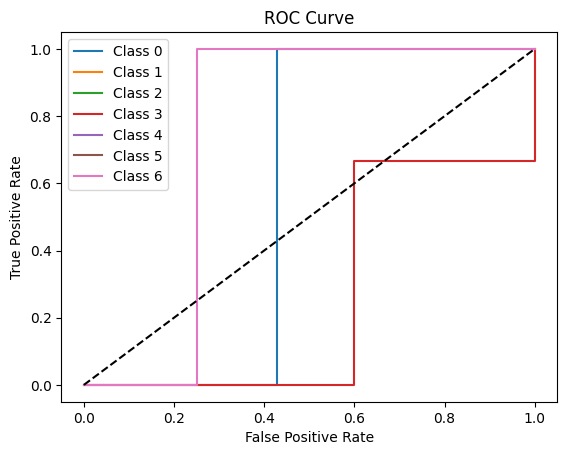

In [12]:
# AUC and ROC
y_val_binarized = label_binarize(y_val, classes=range(num_classes))
y_pred_proba = model.predict(X_val)
auc = roc_auc_score(y_val_binarized, y_pred_proba, multi_class='ovr')
print(f'AUC: {auc}')

fpr = dict()
tpr = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_binarized[:, i], y_pred_proba[:, i])

plt.figure()
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Predict probabilities on validation set
y_score = model.predict(X_val)  # shape: (num_samples, num_classes)

# True labels (one-hot encoded)
y_true = y_val  # shape: (num_samples, num_classes)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown'])
for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} ROC curve (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [16]:
print(y_val.shape)

(8,)
